In [2]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate Sample Dataset

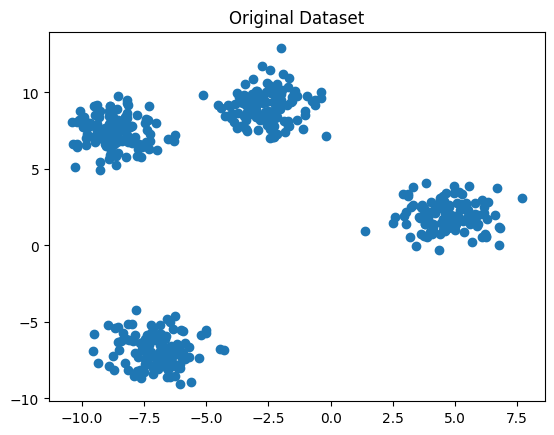

In [4]:
# Create artificial data with 4 natural groups
X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Dataset")
plt.show()

# K-Means Clustering

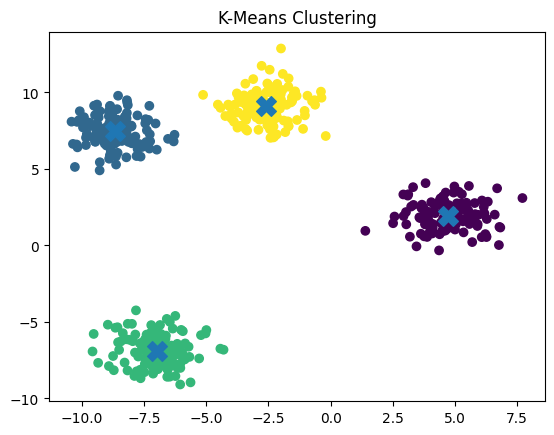

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=clusters)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.title("K-Means Clustering")
plt.show()

# Elbow Method

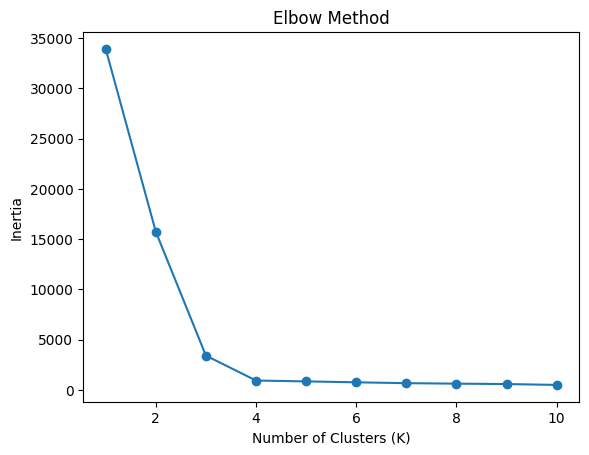

In [6]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [7]:
# The elbow helps us choose a suitable number of clusters.
# After a 4, adding more clusters gives only a small improvement.

# DBSCAN

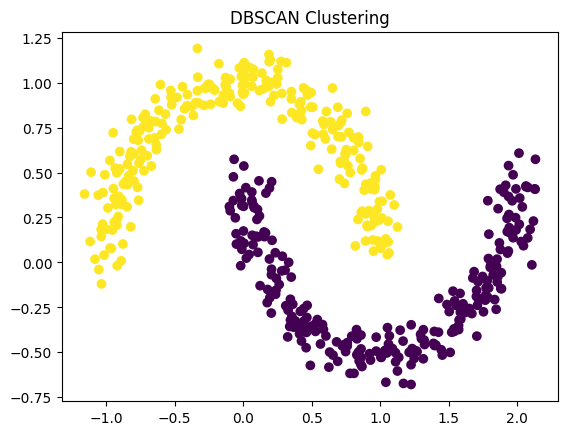

In [8]:
from sklearn.datasets import make_moons

X_moon, _ = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)

dbscan = DBSCAN(eps=0.25, min_samples=5)
db_clusters = dbscan.fit_predict(X_moon)

plt.scatter(
    X_moon[:, 0],
    X_moon[:, 1],
    c=db_clusters
)

plt.title("DBSCAN Clustering")
plt.show()

In [9]:
#K-Means likes round clusters. DBSCAN can discover irregular shapes and can label noise/outliers as -1

# PCA

Original shape: (500, 5)
After PCA: (500, 2)


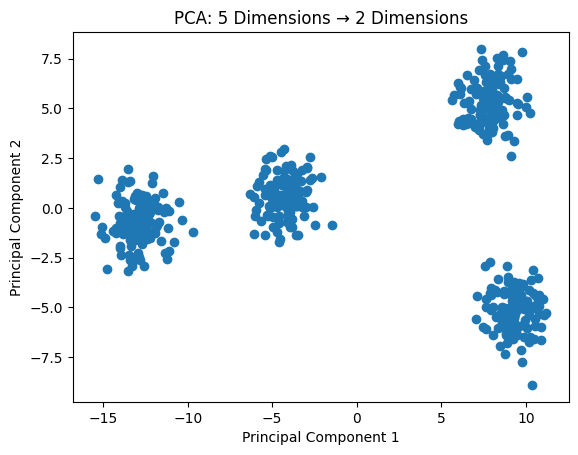

In [10]:
# Create higher-dimensional data
X_high, _ = make_blobs(
    n_samples=500,
    centers=4,
    n_features=5,
    random_state=42
)

print("Original shape:", X_high.shape)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_high)

print("After PCA:", X_pca.shape)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: 5 Dimensions → 2 Dimensions")
plt.show()